# 02 — Modelo de preço/m² de terreno (EDA + treino)

Documenta o alvo, as features e a comparação **baseline × GBM × geo+zona** do modelo de preço/m² de terreno em São Paulo (ITBI público).

**Regra crítica:** o ML modela *apenas* o preço/m² (lado da receita). Viabilidade nunca é alvo de ML — é calculada (fluxo de caixa) e simulada (Monte Carlo). Validação sempre por tempo (treina ≤2023, testa ≥2024).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from loteia.model.experimento_geo import (
    montar_dataset_enriquecido, FEATURES_FINAIS_NUM, FEATURES_FINAIS_CAT,
)
from loteia.model.train import (
    split_temporal, treinar_modelo, avaliar, BaselineMedianaSetor,
    FEATURES, FEATURES_NUM, ALVO,
)
from loteia.model.explain import explicar_global

df = montar_dataset_enriquecido()
print(f'{len(df):,} terrenos limpos | anos: {sorted(df.ano.unique())}')

2,500 terrenos limpos | anos: [np.int64(2023), np.int64(2024)]


/home/henryque/Documents/JOB/loteIA/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## O alvo é log-normal (cauda pesada)

Preço/m² varia de poucos reais a dezenas de milhares — a média é puxada pela cauda. Isso motivou testar log-alvo (ver seção de modelos).

count      2500.0
mean       2132.2
std        5211.2
min           5.9
1%           30.0
5%          103.3
50%        1076.3
95%        7000.0
99%       18307.0
max      121700.6


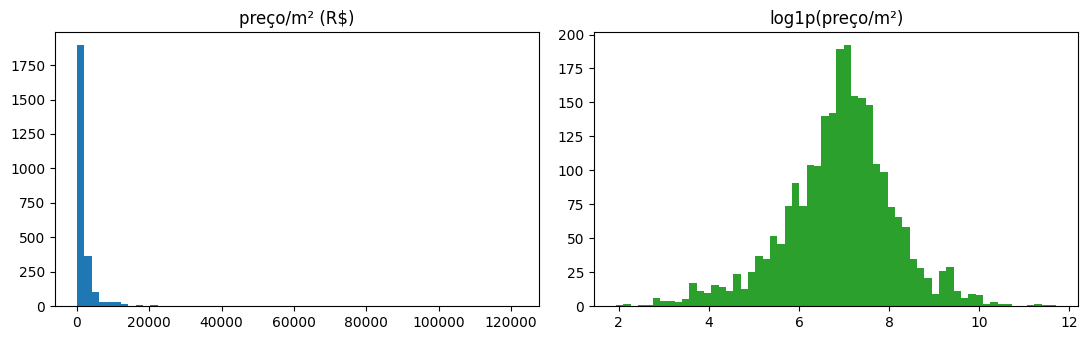

In [2]:
print(df[ALVO].describe(percentiles=[.01,.05,.5,.95,.99]).round(1).to_string())
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df[ALVO], bins=60, color='#1f77b4'); ax[0].set_title('preço/m² (R$)')
ax[1].hist(np.log1p(df[ALVO]), bins=60, color='#2ca02c'); ax[1].set_title('log1p(preço/m²)')
fig.tight_layout()

## Features

- **Cadastrais (ITBI):** área do terreno, testada.
- **Geoespaciais (Camada 5):** x,y do centroide da quadra, distância ao centro e à estação mais próxima, comércio/escolas no raio de 1 km, renda do setor censitário (IBGE) e **zona** (zoneamento PDE 2014).

Custos (gleba, infra) **não** são features — são inputs incertos da simulação.

In [3]:
print('numéricas:', FEATURES_FINAIS_NUM)
print('categóricas:', FEATURES_FINAIS_CAT)
df[FEATURES_FINAIS_NUM].describe().round(1)

numéricas: ['area_terreno_itbi', 'testada', 'dist_centro', 'dist_estacao', 'n_comercio_1km', 'n_escola_1km', 'renda_setor', 'x', 'y']
categóricas: ['zona']


,area_terreno_itbi,testada,dist_centro,dist_estacao,n_comercio_1km,n_escola_1km,renda_setor,x,y
count,2500.0,2500.0,2498.0,2498.0,2500.0,2500.0,2472.0,2498.0,2498.0
mean,631.0,14.6,15538.8,2310.0,19.0,4.1,2619.4,334344.6,7390044.9
std,1940.4,19.9,6518.0,1776.5,51.1,3.1,3478.8,12448.3,10359.8
min,12.0,0.0,991.7,69.4,0.0,0.0,193.2,314648.3,7354194.7
25%,188.0,7.0,10840.7,1014.9,1.0,2.0,954.6,323292.0,7384131.6
50%,275.0,10.0,15028.4,1827.2,4.0,4.0,1439.3,330570.0,7390490.6
75%,480.0,14.0,20221.0,3134.9,14.0,6.0,2734.7,346548.8,7397763.4
max,54638.0,385.8,42377.8,16760.2,833.0,17.0,41175.7,360409.6,7412154.8


## Split temporal e comparação de modelos

Treina com transações ≤2023, testa com ≥2024 (sem embaralhar). Compara a baseline (mediana por setor) contra GBM de 3 features e GBM enriquecido.

In [4]:
train, test = split_temporal(df)
print(f'treino {len(train):,} (≤2023) | teste {len(test):,} (≥2024)')

baseline = BaselineMedianaSetor().fit(train[FEATURES], train[ALVO])
baseline.features_ = FEATURES
m_3f = treinar_modelo(train)
m_geo = treinar_modelo(train, features_num=FEATURES_FINAIS_NUM,
                       features_cat=FEATURES_FINAIS_CAT)
m_log = treinar_modelo(train, features_num=FEATURES_FINAIS_NUM,
                       features_cat=FEATURES_FINAIS_CAT, log_alvo=True)

tabela = pd.DataFrame({
    'baseline mediana/setor': avaliar(baseline, test),
    'GBM 3 features': avaliar(m_3f, test),
    'GBM geo+zona': avaliar(m_geo, test),
    'GBM geo+zona (log)': avaliar(m_log, test),
}).T.round(3)
tabela

treino 1,163 (≤2023) | teste 1,337 (≥2024)


,mae,mape_mediana,r2
baseline mediana/setor,1417.183,0.412,0.180
GBM 3 features,1678.387,0.446,0.074
GBM geo+zona,1268.114,0.340,0.207
GBM geo+zona (log),1299.738,0.383,0.163


**Leitura:** o enriquecimento geoespacial reduz o MAE em ~24% sobre o GBM de 3 features e supera a baseline. Com o conjunto rico de features, o log-alvo deixou de ajudar (o modelo de loss absoluta em escala real vence) — por isso o artefato final **não** usa log. O R² ~0,21 reflete o teto de sinal de localização+área; mais anos de dados (ver notebook 03) é a alavanca de teto.

## Explicabilidade (SHAP global) — Camada 3

Importância média |SHAP| do modelo final (R$/m²): a localização domina.

dist_centro          722.1
renda_setor          312.0
dist_estacao         207.3
n_comercio_1km       183.7
x                    148.2
y                    121.1
zona                 118.5
area_terreno_itbi     68.2
n_escola_1km          56.1
testada               46.6


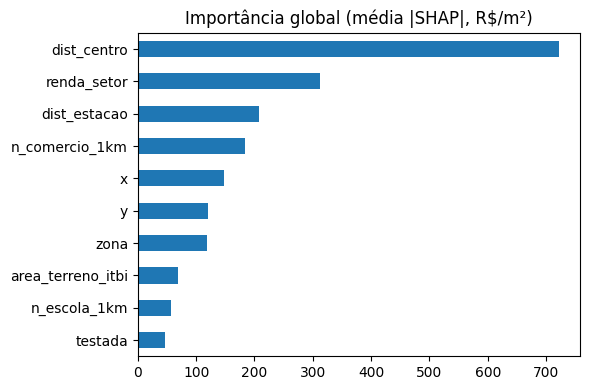

In [5]:
imp = explicar_global(m_geo, train).round(1)
print(imp.to_string())
imp.sort_values().plot.barh(figsize=(6,4), color='#1f77b4',
    title='Importância global (média |SHAP|, R$/m²)')
plt.tight_layout()

A distância ao centro, a renda do setor e as coordenadas lideram. A `zona` tem importância global baixa (a localização contínua já a captura), mas contribui localmente em terrenos específicos. Conclusão: o preço/m² é essencialmente um problema de **localização**, como esperado em terra urbana.